In [1]:
from sklearn.decomposition import TruncatedSVD

from collections import defaultdict

import pandas as pd
import numpy as np
import glob
import os

from sklearn.cluster import KMeans
from tsfresh import extract_features
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
paths = glob.glob("data/log_count/Affluences Logfrequency Data/*.csv")
# paths = glob.glob("data/zg_data/*.csv")
dfs = [pd.read_csv(path, parse_dates=["timestamp"], usecols=["timestamp", "n_message"]) for path in paths]

In [ ]:
# generate shape charts

for p, df in zip(paths, dfs):
    shapename = p.split("/")[-1].replace(".csv", "")
    fig = df.set_index("timestamp").plot(figsize=(15, 4), title=shapename).get_figure()
    fig.savefig(os.path.join("data/clusters/shapes/", shapename + ".png"))
    plt.close()
#     break

In [ ]:
len(dfs)

In [ ]:
path_cluster_dict = {
    p.replace(".png", "").split("/")[-1]: int(p.split("/")[-2])
    for p in glob.glob("data/clusters/labels/*/*.png")
}

In [ ]:
dfs[0].head()

In [ ]:
# indexing data for tsfresh 

to_remove = []
idx_path_dict = {}
for idx, df in enumerate(dfs):
    print("Processing file with idx", idx)
    if df.shape[0] > 10:
        df["time"] = df.apply(lambda x: int(datetime.timestamp(x.timestamp)), axis=1)
        df["id"] = idx + 1
        idx_path_dict[idx + 1] = paths[idx]
    else:
        to_remove.append(idx)

for idx in to_remove:
    dfs.pop(idx)
    print("Removed df with index", idx)

In [ ]:
idx_cluster_dict = {idx: path_cluster_dict[p.replace(".csv", "").split("/")[-1]] for idx, p in idx_path_dict.items()}

In [2]:
def scale_df(df):
    result = df.copy()
    result["n_message"] = MinMaxScaler().fit_transform(result.n_message.values.reshape(-1, 1))
    return result

In [ ]:
for i in range(5):
    print("Cluster", i, ":", Counter(idx_cluster_dict.values())[i], "shapes")

In [3]:
def slice_df(df, step=60 * 24 * 3):
    result = df.copy()
    output = []
    current_cluster = idx_cluster_dict[df["id"][0]]
    if current_cluster == 0:
        num_slices = 2
    elif current_cluster == 1:
        num_slices = 15
        step = 60 * 6
    elif current_cluster == 2:
        num_slices = 2
    elif current_cluster == 3:
        num_slices = 5
    else:
        num_slices = 5
    s = len(result) // step
    for sub_idx, d in enumerate(
        [df[i * step : (i + 1) * step] for i in range(s)][:num_slices]
    ):
        d_temp = d.reset_index(drop=True)
        d_temp["id"] = str(d_temp["id"][0]) + f"_{sub_idx}"
        output.append(d_temp)
    return output

In [ ]:
# # data preparation without slicing
# data = pd.concat([scale_df(df[: 60 * 24 * 3]) for df in dfs])[
#     ["id", "time", "n_message"]
# ].sort_values(by=["id", "time"])

In [ ]:
# data preparation with slicing
t = list(map(slice_df, [scale_df(df) for df in dfs]))
data = pd.concat([item for sublist in t for item in sublist])[
    ["id", "time", "n_message"]
].sort_values(by=["id", "time"])

In [ ]:
data.shape

In [ ]:
print("Number of dataframes per cluster:")
for i in range(5):
    print("Cluster", i, ":", dict(Counter([idx_cluster_dict[int(i.split("_")[0])] for i in np.unique(data.id)]))[i], "samples")

In [ ]:
X = data.copy()

In [ ]:
data.shape, X.shape

In [ ]:
features = extract_features(X, column_id="id", column_sort="time")

In [ ]:
print("features shape:", features.shape, ",", "number of different timeseries:", len(X.id.unique()))

In [ ]:
X_features = features.dropna(axis=1)

In [ ]:
X_features

In [ ]:
X_features.shape

### RF for feature importance

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle

In [ ]:
# X_features.to_csv("data/temp_files/X_features.csv")

# # save the model to disk
# filename = "data/temp_files/RF_model.sav"
# pickle.dump(model, open(filename, "wb"))

# pd.to_pickle(idx_cluster_dict, "data/temp_files/idx_cluster_dict.pickle")

# # load the model from disk
# loaded_model = pickle.load(open(filename, 'rb'))
# print(loaded_model.score(X_test_RF, y_test_RF))

In [ ]:
# with slicing
y_RF = (
    X_features.reset_index()["index"]
    .apply(lambda x: idx_cluster_dict[int(x.split("_")[0])])
    .values.ravel()
)
X_RF = X_features.values
X_train_RF, X_test_RF, y_train_RF, y_test_RF = train_test_split(
    X_RF, y_RF, test_size=0.33, random_state=42, stratify=y_RF
)
# define the model
model = RandomForestClassifier()
# fit the model
model.fit(X_train_RF, y_train_RF)

In [ ]:
print(classification_report(y_true=y_test_RF, y_pred=model.predict(X_test_RF)))

In [ ]:
! open .

In [ ]:
# # without slicing
# y_RF = X_features.reset_index().replace({"index": idx_cluster_dict})[["index"]]
# X_RF = X_features.copy()
# # define the model
# model = RandomForestClassifier()
# # fit the model
# model.fit(X_RF.values, y_RF.values.ravel())

In [ ]:
# get importance
importance = model.feature_importances_
# # summarize feature importance
# for i,v in enumerate(importance):
#     print('Feature: %0d, Score: %.5f' % (i,v))

feature_importance_dict = dict(zip(X_features.columns, importance))

In [ ]:
top_features = [f[0] for f in sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)[:10]]
print(top_features)

### Evaluation using new data

In [5]:
paths = glob.glob("data/zg_data/*.csv")
dfs_zg = [pd.read_csv(path, parse_dates=["timestamp"], usecols=["timestamp", "n_message"]) for path in paths]

In [6]:
# indexing data for tsfresh 

to_remove = []
idx_path_dict = {}
for idx, df in enumerate(dfs_zg):
    print("Processing file with idx", idx)
    if df.shape[0] > 10:
        df["time"] = df.apply(lambda x: int(datetime.timestamp(x.timestamp)), axis=1)
        df["id"] = idx + 1
        idx_path_dict[idx + 1] = paths[idx]
    else:
        to_remove.append(idx)

for idx in to_remove:
    dfs_zg.pop(idx)
    print("Removed df with index", idx)

Processing file with idx 0
Processing file with idx 1
Processing file with idx 2
Processing file with idx 3
Processing file with idx 4
Processing file with idx 5
Processing file with idx 6
Processing file with idx 7
Processing file with idx 8
Processing file with idx 9
Processing file with idx 10
Processing file with idx 11
Processing file with idx 12
Processing file with idx 13
Processing file with idx 14
Processing file with idx 15
Processing file with idx 16
Processing file with idx 17
Processing file with idx 18
Processing file with idx 19
Processing file with idx 20


In [7]:
data_zg = pd.concat([scale_df(df[: 60 * 24 * 7]) for df in dfs_zg])[
    ["id", "time", "n_message"]
].sort_values(by=["id", "time"])

In [8]:
data_zg.shape

(205634, 3)

In [9]:
features_zg = extract_features(data_zg, column_id="id", column_sort="time")
X_features_zg = features_zg.dropna(axis=1)

Feature Extraction: 100%|██████████| 21/21 [16:23<00:00, 46.82s/it]  


In [10]:
# # load the model from disk
filename = "data/temp_files/RF_model.sav"
with open(filename, 'rb') as f:
    loaded_model = pickle.load(f)

In [11]:
temp = pd.read_csv("data/temp_files/X_features.csv", index_col="Unnamed: 0")

In [12]:
X_features_zg.shape

(21, 774)

In [13]:
X_RF_eval = X_features_zg[temp.columns].values
zg_clusters = loaded_model.predict(X_RF_eval)

'usually the same values observed : 0.31\ndense data around the mean value : 0.06\nrandom noisy data : 0.17\nsparse data with no patterns : 0.11\ndata with seasonal patterns : 0.35'

In [14]:
cluster_description = {
    0: "usually the same values observed",
    1: "dense data around the mean value",
    2: "random noisy data",
    3: "sparse data with no patterns",
    4: "data with seasonal patterns",
}

/opt/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/core.py:337: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = self.plt.figure(figsize=self.figsize)


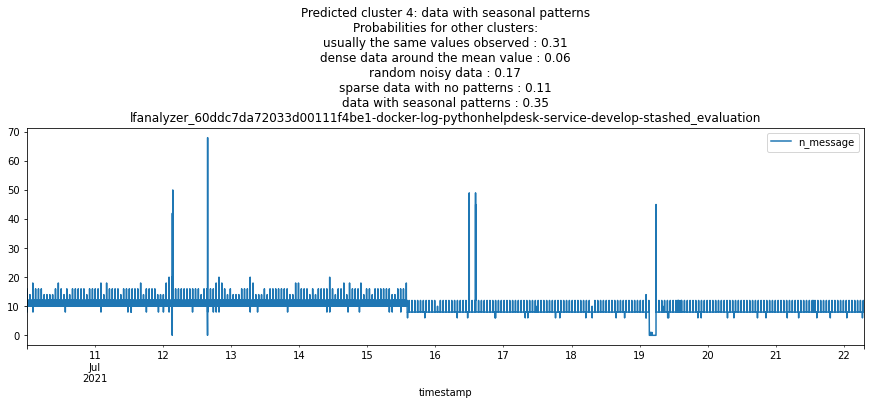

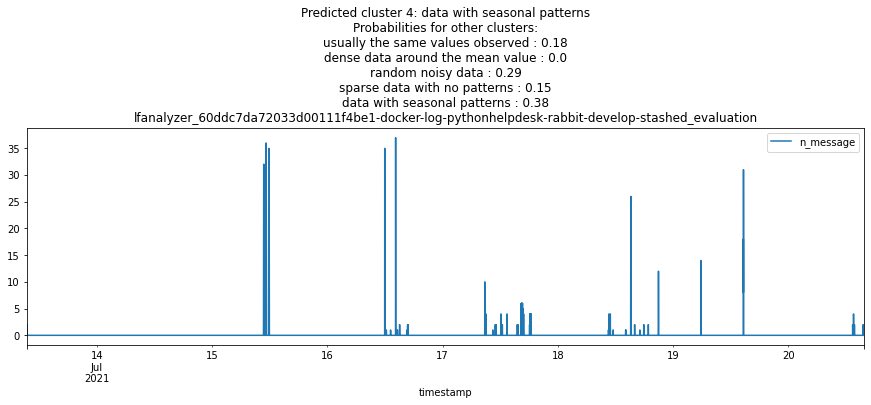

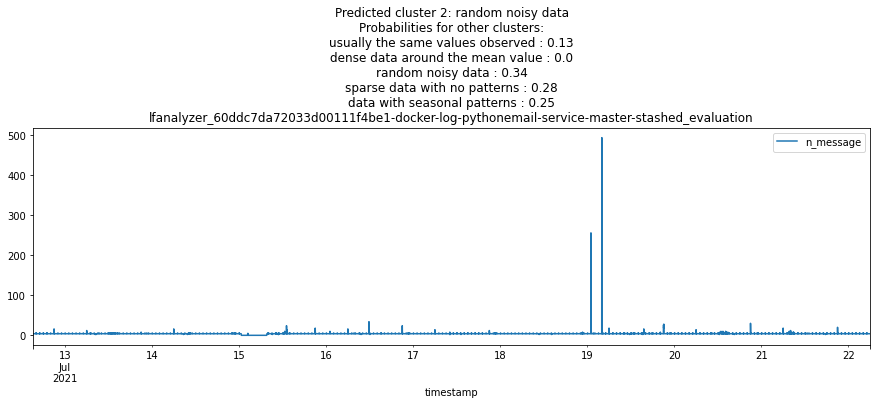

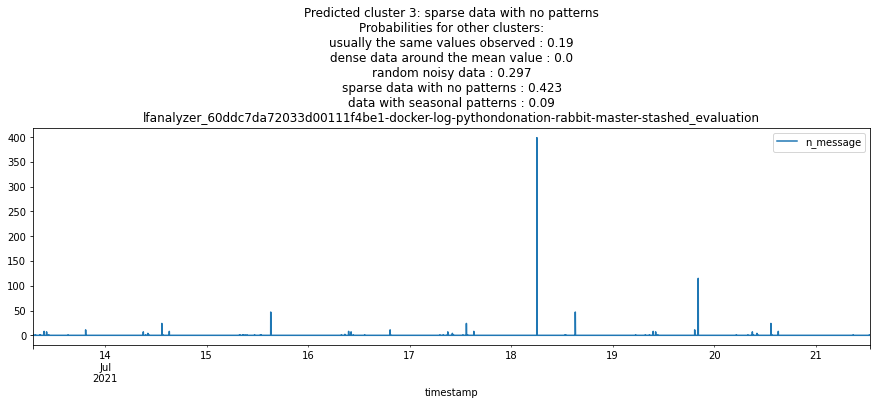

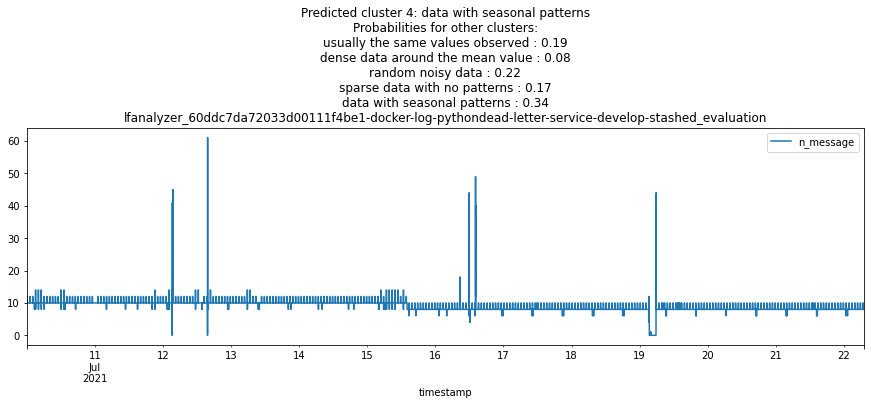

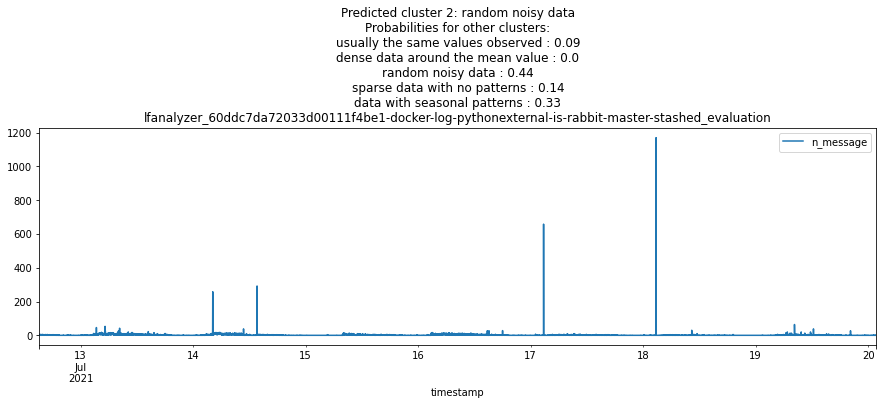

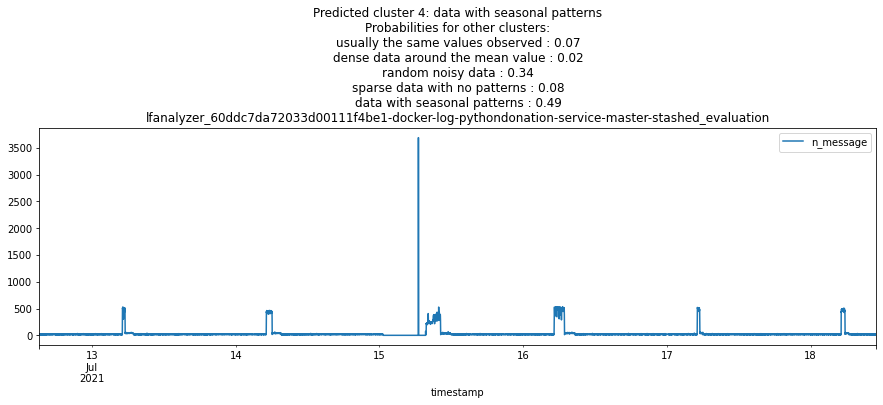

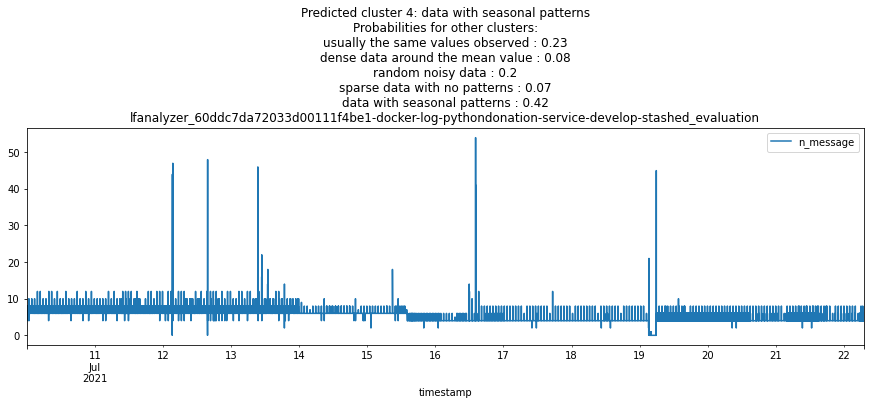

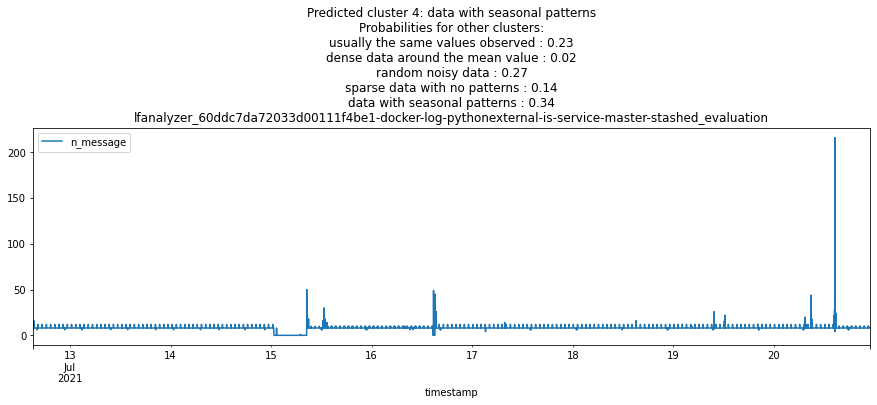

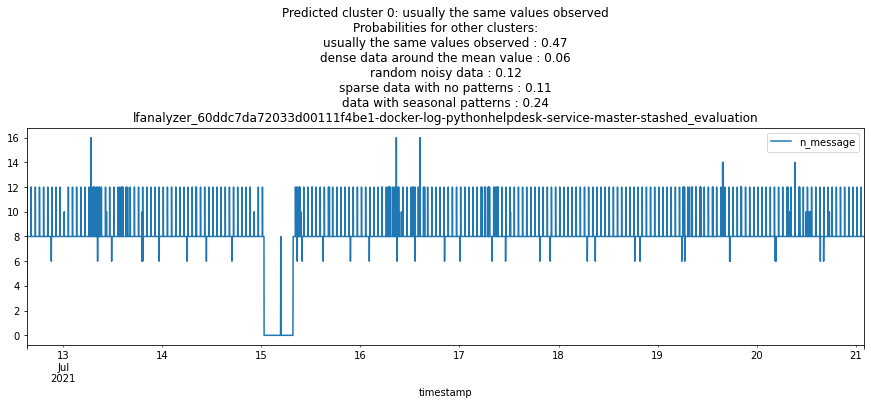

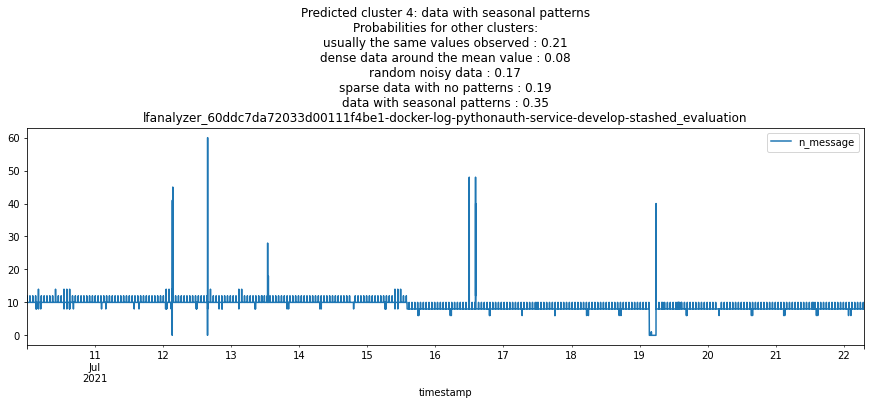

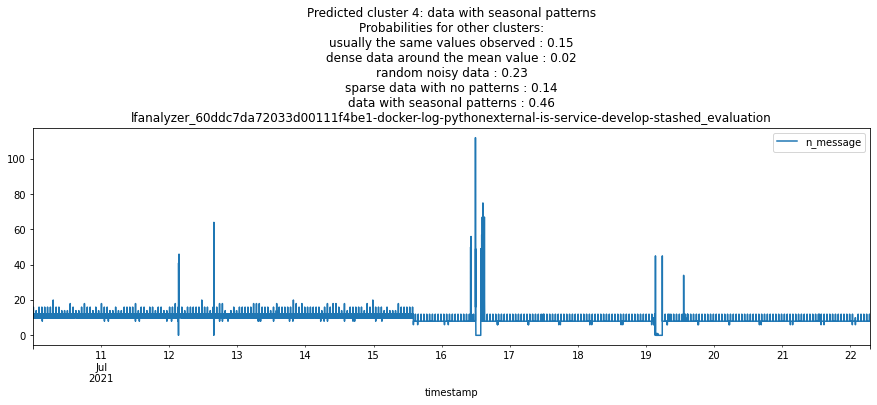

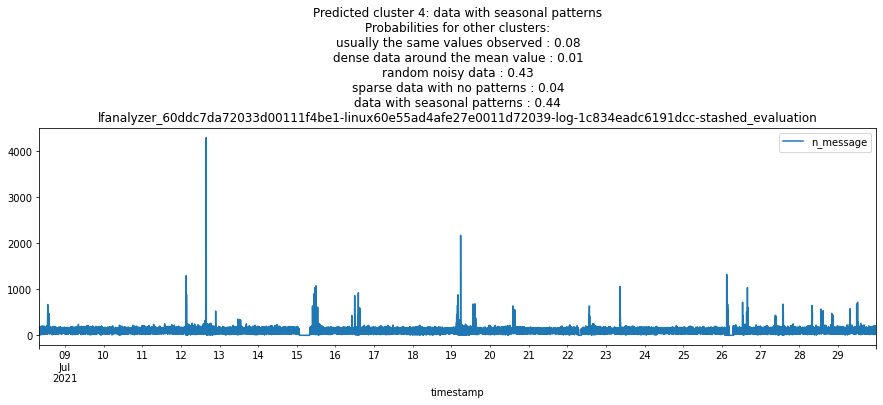

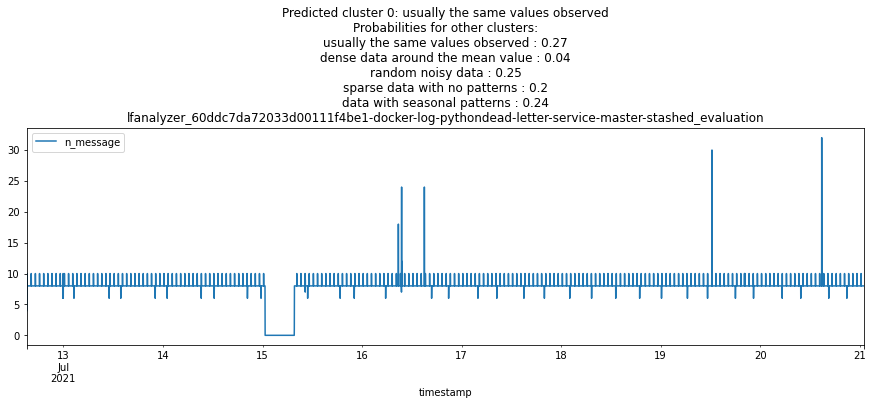

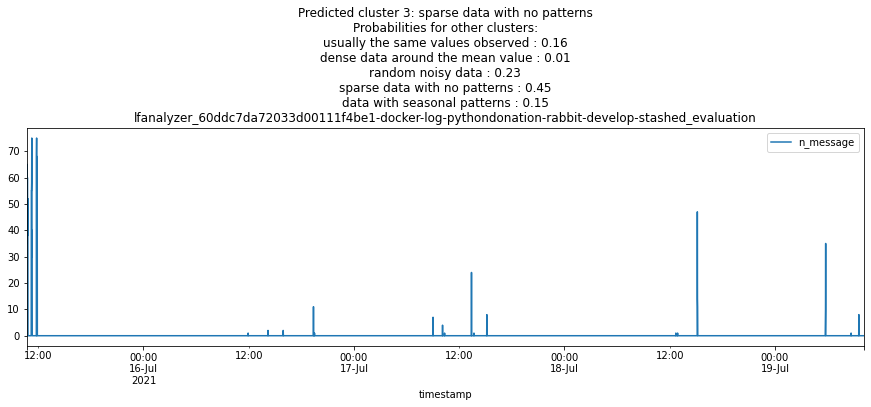

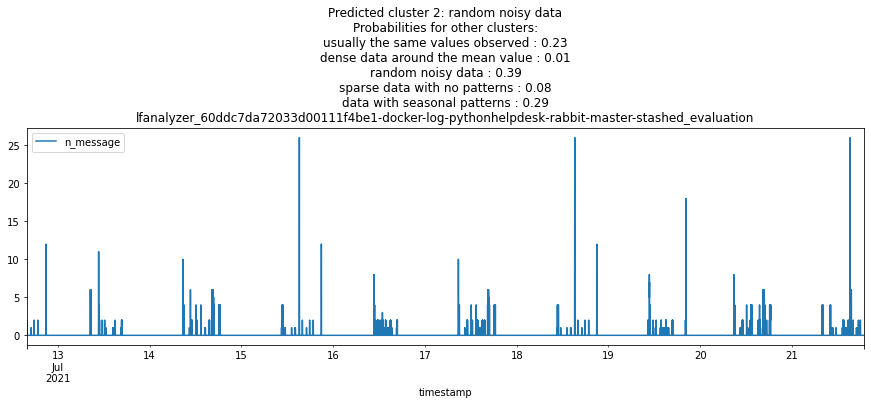

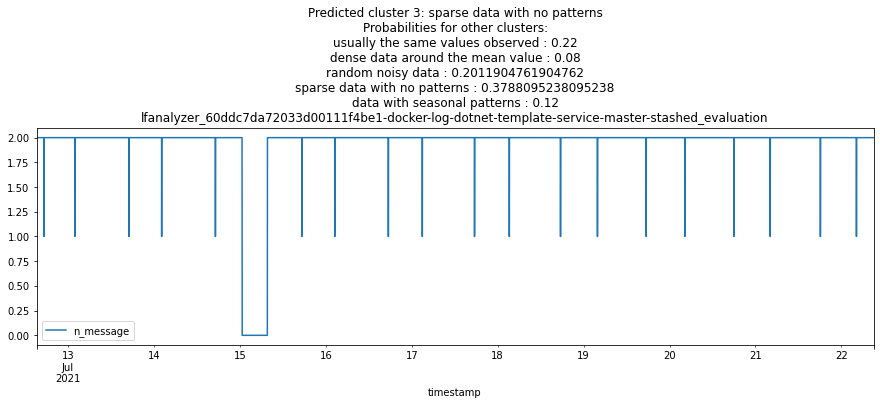

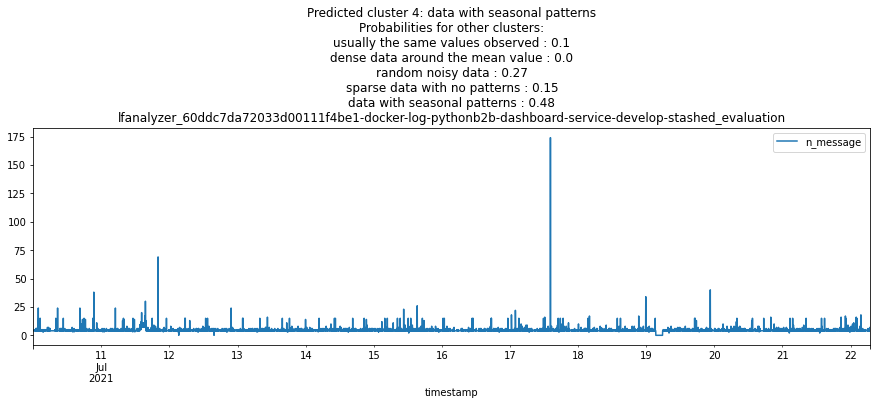

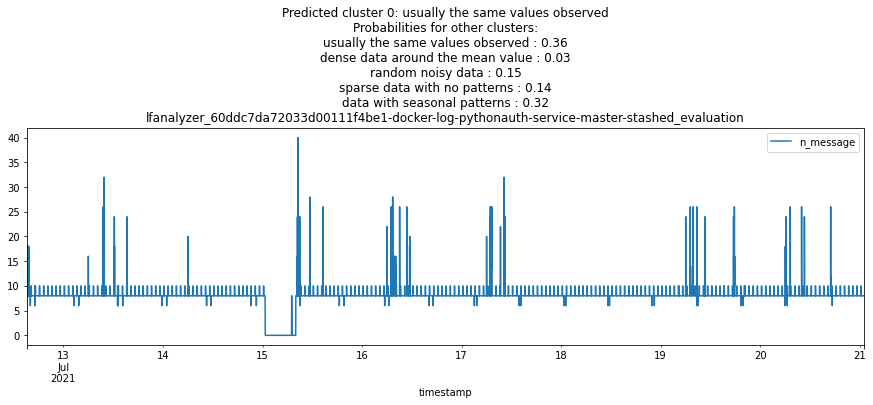

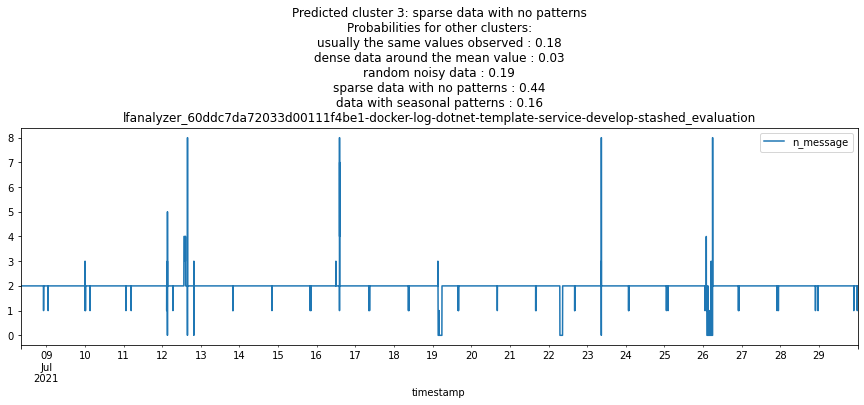

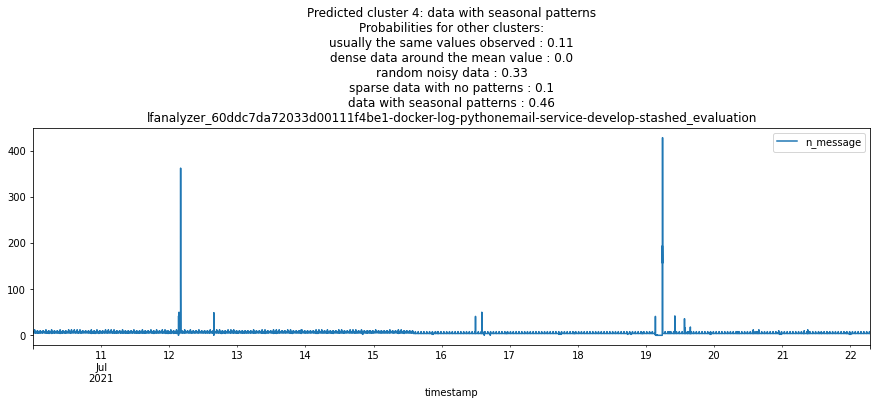

In [36]:
for idx, c in enumerate(zg_clusters, start=1):
    df = pd.read_csv(idx_path_dict[idx], parse_dates=["timestamp"]).set_index(
        "timestamp"
    )
    proba = loaded_model.predict_proba(X_RF_eval)[idx - 1]
    proba_str = "\n".join(
        [f"{cluster_description[i]} : {j}" for i, j in zip(range(len(proba)), proba)]
    )
    name = idx_path_dict[idx].split("/")[-1].replace(".csv", "_evaluation")
    ax = df.plot(
        figsize=(15, 4),
        title=f"Predicted cluster {c}: {cluster_description[c]}\nProbabilities for other clusters:\n{proba_str}\n"
        + name,
    )
    ax.get_figure().savefig("results/evaluation/" + name + ".png", bbox_inches='tight')

In [35]:
! open .

### Avg features per cluster

In [ ]:
# cluster_features = X_features.reset_index().replace({"index": idx_cluster_dict}).groupby("index").mean()

In [ ]:
cluster_features = X_features.reset_index().copy()
cluster_features["index"] = X_features.reset_index()["index"].apply(
    lambda x: idx_cluster_dict[int(x.split("_")[0])]
)
cluster_features = cluster_features.groupby("index").mean()

In [ ]:
cluster_features.reset_index()[top_features]

In [ ]:
from math import pi

# Set data
df = pd.DataFrame(
    {
        "index": ["A", "B", "C", "D"],
        "var1": [38, 1.5, 30, 4],
        "var2": [29, 10, 9, 34],
        "var3": [8, 39, 23, 24],
        "var4": [7, 31, 33, 14],
        "var5": [28, 15, 32, 14],
    }
)

# ------- PART 1: Define a function that do a plot for one line of the dataset!


def make_spider(row, title, color):

    # number of variable
    categories = list(df)[1:]
    N = len(categories)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialise the spider plot
    ax = plt.subplot(5, 1, row + 1, polar=True,)

    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color="grey", size=8)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.1, 0.5, 0.9], ["0.1", "0.5", "0.9"], color="grey", size=7)
    plt.ylim(0, 1.1)

    # Ind1
    values = df.loc[row].drop("index").values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle="solid")
    ax.fill(angles, values, color=color, alpha=0.4)

    # Add a title
    plt.title(title, size=11, color=color, y=1.1)
#     ax.get_figure().savefig("results/radar/cluster" + str(color) + ".png")

In [ ]:
top_features

In [ ]:
df

In [ ]:
top_features = ['n_message__agg_linear_trend__attr_"intercept"__chunk_len_5__f_agg_"var"',
 'n_message__cid_ce__normalize_False',
 'n_message__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.6',
 'n_message__absolute_sum_of_changes',
 'n_message__agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"max"',
 'n_message__approximate_entropy__m_2__r_0.1',
 'n_message__ratio_beyond_r_sigma__r_1',
 'n_message__percentage_of_reoccurring_datapoints_to_all_datapoints',
 'n_message__number_peaks__n_50',
 'n_message__ar_coefficient__coeff_1__k_10']

In [ ]:
# ------- PART 2: Apply the function to all individuals
# initialize the figure
my_dpi = 96
plt.figure(figsize=(1000 / my_dpi, 3000 / my_dpi), dpi=my_dpi)

df = cluster_features[top_features]
df -= df.min()
df /= df.max()
df = df.reset_index()

cluster_description = {
    0: "usually the same values observed",
    1: "dense data around the mean value",
    2: "random noisy data",
    3: "sparse data with no patterns",
    4: "data with seasonal patterns",
}
# Create a color palette:
my_palette = plt.cm.get_cmap("Set2", len(df.index))

# Loop to plot
for row in range(0, len(df.index)):
    make_spider(
        row=row,
        title="Cluster "
        + str(df["index"][row])
        + f" ({cluster_description[df['index'][row]]})",
        color=my_palette(row),
    )
plt.tight_layout()
plt.savefig("results/radar/cluster.png", dpi=600)

In [ ]:
cluster_features[cluster_features.columns[(cluster_features.std() > 0.01).values]]

### Clustering using PCA

In [ ]:
mode = "PCA"
n_clusters = 5
if mode == "PCA":
    PCA_data = TruncatedSVD(n_components=6).fit_transform(X_features)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(PCA_data)
else:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X_features)

In [ ]:
clusters = kmeans.labels_

In [ ]:
X_features.reset_index()["index"].values

In [ ]:
clustered_paths = defaultdict(list)
for p, c in dict(zip([idx_path_dict[i] for i in X_features.reset_index()["index"].values], clusters)).items():
    clustered_paths[c].append(p)

In [ ]:
# clustered_paths = defaultdict(list)

# for i, c in enumerate(clusters):
#     clustered_paths[c].append(paths[i])

In [ ]:
def plot_clusters_by_path(paths):
    dfs = [pd.read_csv(path, parse_dates=["timestamp"]) for path in paths]
    if len(dfs) > 1:
        figure, axes = plt.subplots(len(dfs), 1, figsize=(15, 4 * len(dfs)))
        for i, df in enumerate(dfs):
            if len(df) > 0:
                df.set_index("timestamp")[["n_message"]].plot(
                    ax=axes[i], title=paths[i].split("/")[-1]
                )
        figure.tight_layout()
    else:
        dfs[0].set_index("timestamp")[["n_message"]].plot(
            title=paths[0].split("/")[-1], figsize=(15, 4 * len(dfs))
        )

In [ ]:
clustered_paths.keys()

In [ ]:
clusters

In [ ]:
plot_clusters_by_path(clustered_paths[0])

In [ ]:
plot_clusters_by_path(clustered_paths[1])

In [ ]:
plot_clusters_by_path(clustered_paths[2])

In [ ]:
plot_clusters_by_path(clustered_paths[3])

In [ ]:
plot_clusters_by_path(clustered_paths[4])

## tslearn

In [ ]:
from tslearn.utils import to_time_series
from tslearn.clustering import TimeSeriesKMeans

In [ ]:
n_points = 10 * 60 * 24
data = pd.concat([scale_df(df[: n_points]) for df in dfs])[
    ["id", "time", "n_message"]
].sort_values(by=["id", "time"])

In [ ]:
data.n_message.values

In [ ]:
my_first_time_series = []
taken_idx = []
for idx, df in data.groupby("id"):
    if len(df) == n_points:
        my_first_time_series.append(df.n_message.values) 
        taken_idx.append(idx)
X_train = to_time_series(my_first_time_series)

In [ ]:
len(X_train)

In [ ]:
km = TimeSeriesKMeans(n_clusters=5)#, metric="dtw")
km.fit(X_train)

In [ ]:
km.labels_

In [ ]:
clustered_paths = defaultdict(list)
for p, c in dict(zip([idx_path_dict[i] for i in taken_idx], km.labels_)).items():
    clustered_paths[c].append(p)

In [ ]:
plot_clusters_by_path(clustered_paths[0])

In [ ]:
plot_clusters_by_path(clustered_paths[1])

In [ ]:
plot_clusters_by_path(clustered_paths[2])

In [ ]:
plot_clusters_by_path(clustered_paths[3])

In [ ]:
plot_clusters_by_path(clustered_paths[4])

## Generating features

In [ ]:
def generate_features(df):
    mean = df["n_message"].mean()
    std = df["n_message"].std()
    unique_vals_count = len(df["n_message"].value_counts())
    median = df["n_message"].median()
    more_than_quantile95 = df[df["n_message"] > df["n_message"].quantile(.95)].shape[0] / df.shape[0]
    fraction_of_zeros = df[df["n_message"] == 0].shape[0] / df.shape[0]
    fraction_of_nonzeros = df[df["n_message"] != 0].shape[0] / df.shape[0]
    return pd.DataFrame(
        {
            "mean": [mean],
            "std": [std],
            "unique_vals_count": [unique_vals_count],
            "median": [median],
            "more_than_quantile95": [more_than_quantile95],
            "fraction_of_zeros": [fraction_of_zeros],
            "fraction_of_nonzeros": [fraction_of_nonzeros],
        }
    )

In [ ]:
def split_into_buckets(df, n_buckets=10):
    step = len(df) // n_buckets
    res = [df[i*step: (i+1)*step] for i in range(n_buckets)]
    return res

In [ ]:
def process(df, n=100):
    general_features = generate_features(df)
    # diff
    diff_general_features = generate_features(df.diff().dropna())
    diff_general_features.columns = [
        "diff_" + col for col in diff_general_features.columns
    ]
    # bucket split
    df2 = pd.concat(map(generate_features, split_into_buckets(df, n_buckets=n)))
    # mean bucket
    mean_bucket = pd.DataFrame(df2.mean()).T
    mean_bucket.columns = ["mean_bucket_" + col for col in mean_bucket.columns]
    # std bucket
    std_bucket = pd.DataFrame(df2.std()).T
    std_bucket.columns = ["std_bucket_" + col for col in std_bucket.columns]
    # bucket split for diff
    df3 = pd.concat(
        map(generate_features, split_into_buckets(df.diff().dropna(), n_buckets=n))
    )
    # mean bucket
    mean_bucket_diff = pd.DataFrame(df3.mean()).T
    mean_bucket_diff.columns = [
        "mean_bucket_diff_" + col for col in mean_bucket_diff.columns
    ]
    # std bucket
    std_bucket_diff = pd.DataFrame(df3.std()).T
    std_bucket_diff.columns = [
        "std_bucket_diff_" + col for col in std_bucket_diff.columns
    ]
    # result
    result = pd.concat(
        [
            general_features,
            mean_bucket,
            std_bucket,
            mean_bucket_diff,
            std_bucket_diff,
            diff_general_features,
        ],
        axis=1,
    )
    result["id"] = df["id"][0]
    return result.set_index("id")

In [ ]:
process(dfs[0])

In [ ]:
X_train_custom_features = pd.concat(map(process, map(scale_df, dfs)))

In [ ]:
X_train_custom_features[["fraction_of_zeros", "unique_vals_count"]].plot.scatter(
    y="unique_vals_count", x="fraction_of_zeros"
)

In [ ]:
mode = "PCA"
n_clusters = 4
if mode == "PCA":
    PCA_data = TruncatedSVD(n_components=10).fit_transform(X_train_custom_features)
    custom_features_kmeans = KMeans(n_clusters=n_clusters).fit(PCA_data)
else:
    custom_features_kmeans = KMeans(n_clusters=n_clusters).fit(X_train_custom_features)

In [ ]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    # Building and fitting the model
    kmeanModel = KMeans(n_clusters=k).fit(PCA_data)

    distortions.append(
        sum(np.min(cdist(PCA_data, kmeanModel.cluster_centers_, "euclidean"), axis=1))
        / PCA_data.shape[0]
    )
    inertias.append(kmeanModel.inertia_)

    mapping1[k] = (
        sum(np.min(cdist(PCA_data, kmeanModel.cluster_centers_, "euclidean"), axis=1))
        / PCA_data.shape[0]
    )
    mapping2[k] = kmeanModel.inertia_

In [ ]:
plt.plot(K, distortions, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

In [ ]:
custom_features_kmeans.labels_

In [ ]:
from collections import Counter
Counter(custom_features_kmeans.labels_)

In [ ]:
result_custom_features = X_train_custom_features.copy()
result_custom_features["cluster"] = custom_features_kmeans.labels_

In [ ]:
clustered_paths_custom_features = defaultdict(list)
for idx, c in result_custom_features["cluster"].to_dict().items():
    clustered_paths_custom_features[c].append(idx_path_dict[idx])

In [ ]:
plot_clusters_by_path(clustered_paths_custom_features[0])

In [ ]:
plot_clusters_by_path(clustered_paths_custom_features[1])

In [ ]:
plot_clusters_by_path(clustered_paths_custom_features[2])

In [ ]:
plot_clusters_by_path(clustered_paths_custom_features[3])

In [ ]:
paths